# **incêndios florestais no Brasil** <p>
Os incêndios florestais são um grave problema para a preservação das Florestas Tropicais. Compreender a frequência de incêndios florestais em uma série temporal pode ajudar a tomar medidas para evitá-los.
O Brasil tem a maior floresta tropical do planeta que é a floresta amazônica.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('Dados_Indendio.csv', encoding='latin-1')

In [ ]:
df.head()

,year,state,month,number,date
0,1998,Acre,Janeiro,0.0,1998-01-01
1,1999,Acre,Janeiro,0.0,1999-01-01
2,2000,Acre,Janeiro,0.0,2000-01-01
3,2001,Acre,Janeiro,0.0,2001-01-01
4,2002,Acre,Janeiro,0.0,2002-01-01


In [ ]:
df.isnull().sum()

,0
year,0
state,0
month,0
number,0
date,0


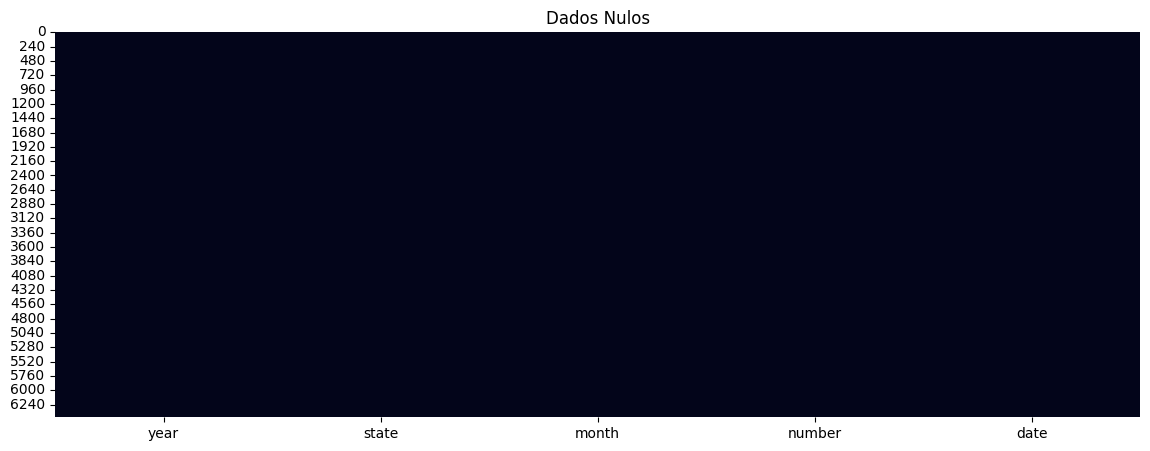

In [ ]:
plt.figure(figsize=(14,5))
plt.title('Dados Nulos')
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6454 entries, 0 to 6453
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    6454 non-null   int64  
 1   state   6454 non-null   object 
 2   month   6454 non-null   object 
 3   number  6454 non-null   float64
 4   date    6454 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.2+ KB


In [ ]:
df.describe()

,year,number
count,6454.000000,6454.000000
mean,2007.461729,108.293163
std,5.746654,190.812242
min,1998.000000,0.000000
25%,2002.000000,3.000000
50%,2007.000000,24.000000
75%,2012.000000,113.000000
max,2017.000000,998.000000


In [ ]:
df.nunique()

,0
year,20
state,23
month,12
number,1479
date,20


Text(0, 0.5, 'Periodo')

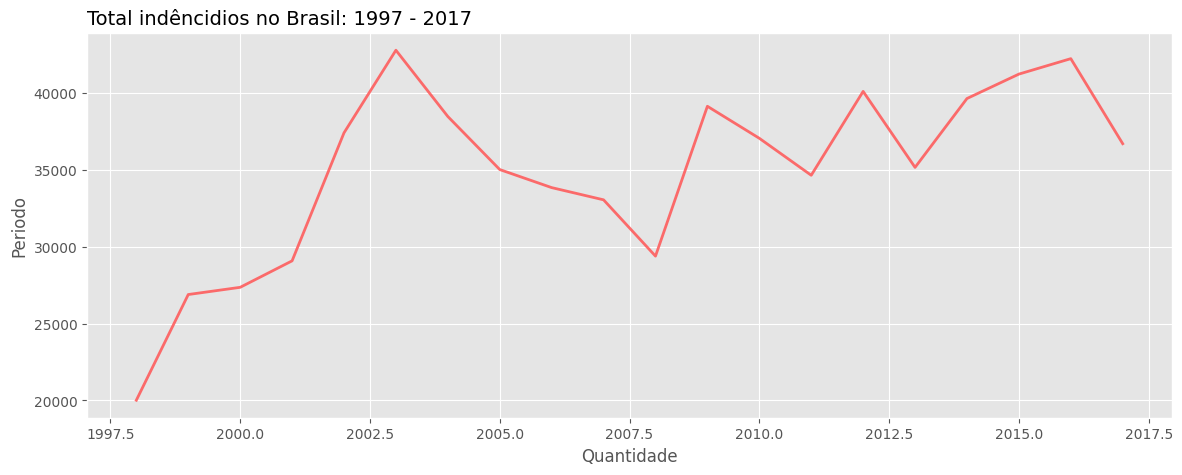

In [ ]:
# analise por ano dos incendios
analise = df.groupby(by=['year']).sum().reset_index()
analise.head()

plt.figure(figsize=(14,5))

plt.style.use('ggplot')

plt.title( 'Total indêncidios no Brasil: 1997 - 2017', loc='left', fontsize=14)
sns.lineplot(data=analise, x='year', y='number', estimator='sum',  lw=2, color='#ff5555', alpha=0.85)

plt.xlabel('Quantidade')
plt.ylabel('Periodo')

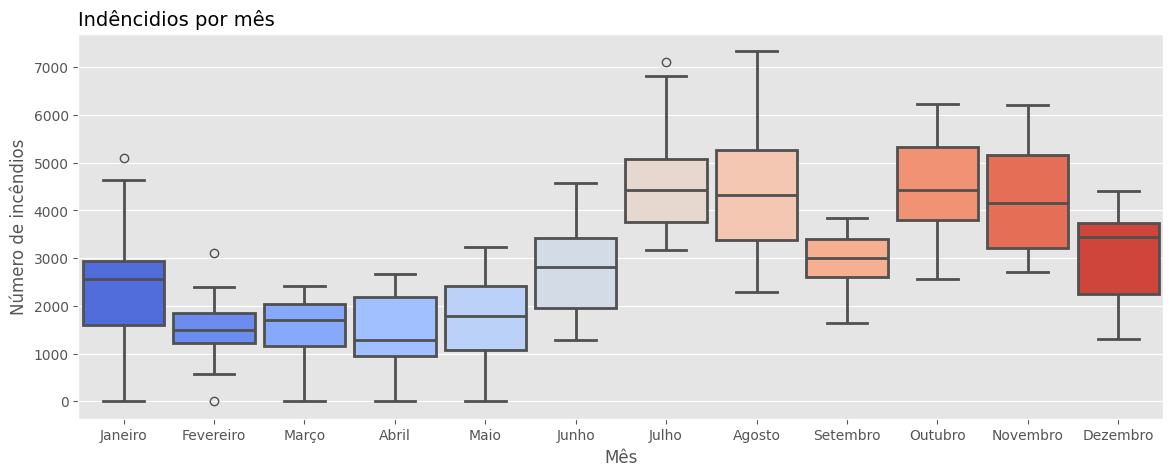

In [27]:
# analiise por ano dos incendios
analise_02 = df.groupby(by=['year', 'month']).sum().reset_index()
analise_02.head()

plt.figure(figsize=(14,5))

plt.style.use('ggplot');

plt.title( 'Indêncidios por mês', loc='left', fontsize=14)

sns.boxplot( data=analise_02, x='month', y='number', palette='coolwarm', saturation=1, width=0.9, linewidth=2,
            order=['Janeiro', 'Fevereiro', 'Março', 'Abril', 'Maio', 'Junho', 'Julho', 'Agosto', 'Setembro', 'Outubro', 'Novembro', 'Dezembro'] )

plt.xlabel('Mês')
plt.ylabel('Número de incêndios');

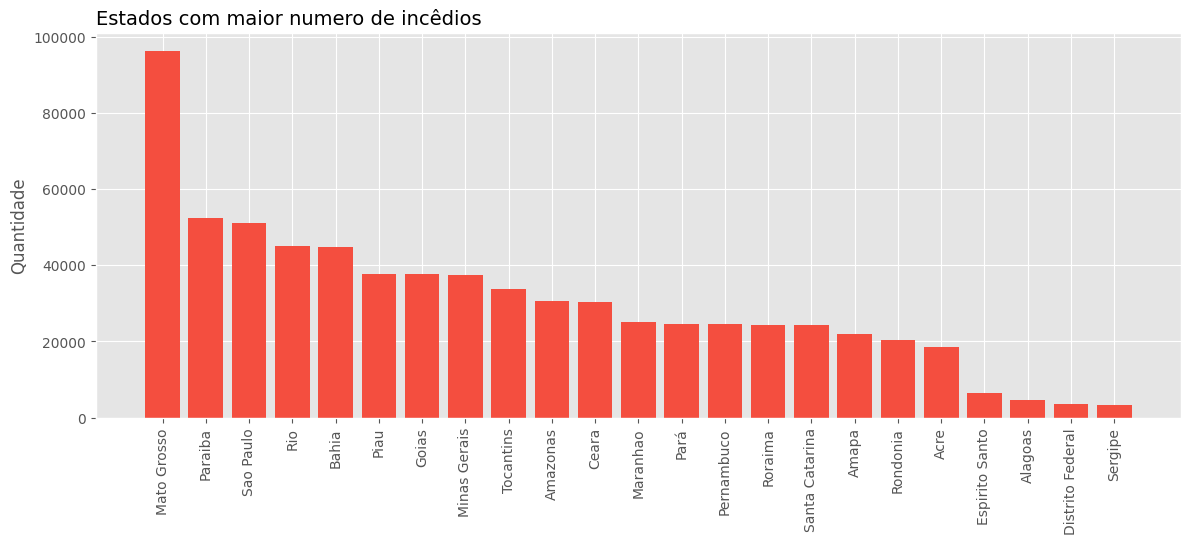

In [30]:
# analise dos incendios por estados
analise_03 = df.groupby(by=['state']).sum().reset_index()[['state', 'number']].sort_values('number', ascending=False )
analise_03.head()

plt.figure(figsize=(14,5))

plt.title('Estados com maior numero de incêdios', loc='left', fontsize=14)

plt.bar(analise_03.state, analise_03['number'], color='#f44e3f')

plt.ylabel('Quantidade')
plt.xticks(rotation=90)
plt.show()

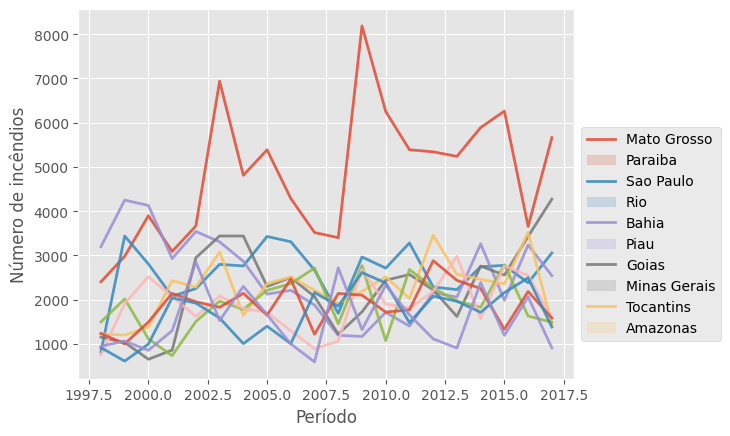

In [36]:
# Estados TOP 10
Lista_TOP10 = analise_03['state'][0:10].values
Lista_TOP10

for Coluna in Lista_TOP10:

  # Filtrar o estado
  Filtro = df.loc[ df['state'] == Coluna ]

  # Agrupar os valores para sumarizar
  Analise_Local = Filtro.groupby( by=['year'] ).sum().reset_index()

  # Plot
  sns.lineplot(data=Analise_Local, x='year', y='number', lw=2, alpha=0.85)

# Labels
plt.xlabel('Período')
plt.ylabel('Número de incêndios')

# Legenda
plt.legend( Lista_TOP10, bbox_to_anchor=(1, 0.7) );

In [38]:
# Plot Geográfico

# Gerando os estados
Estados = analise_03.sort_values('state')['state'].values

# Gerando os valores
Valores = analise_03.sort_values('state')['number'].values

# Latitudes
Lat = [ -8.77, -9.71,	1.41, -3.07,	-12.96, -3.71, -15.83, -19.19, -16.64, -2.55,	-12.64,
       -18.10, -7.06, -5.53, -8.28, -8.28,	-22.84,	-11.22,	1.89,	-27.33,	-23.55,	-10.90,	-10.25 ]

# Longitudes
Log = [ -70.55,	-35.73,	-51.77,	-61.66,	-38.51,	-38.54,	-47.86,	-40.34,	-49.31,	-44.30,	-55.42,	-44.38,
       -35.55,	-52.29,	-35.07,	-43.68,	-43.15,	-62.80,	-61.22,	-49.44,	-46.64,	-37.07,	-48.25 ]

# Organizados os dados
Dicionario = {
    'Estados' : Estados,
    'Latitude' : Lat,
    'Longitude' : Log,
    'Incêndios' : Valores
}

# Lendo o dicionario
Analise_Geografica = pd.DataFrame ( Dicionario )

Analise_Geografica.head()

,Estados,Latitude,Longitude,Incêndios
0,Acre,-8.77,-70.55,18464.030
1,Alagoas,-9.71,-35.73,4644.000
2,Amapa,1.41,-51.77,21831.576
3,Amazonas,-3.07,-61.66,30650.129
4,Bahia,-12.96,-38.51,44746.226


In [39]:
# Fazendo o plot
import plotly.express as px

# Mapa de CAlor Geografico
px.density_mapbox(
    Analise_Geografica,
    lat='Latitude',
    lon='Longitude',
    z='Incêndios',
    radius=30,
    center=dict(lat=-12.700, lon=-46.5555),
    zoom=3,
    mapbox_style='stamen-terrain'
)